In [1]:
import torch # главная библиотека, в торче лежит всё
from torch.utils.data import Dataset, DataLoader # Dataset - хранилище данных, DataLoader - загрузчик, через который мы будем получать данные
from torch.optim import AdamW # наш оптимизатор, он смотрит на ошибку и меняет веса, чтобы сеть лучше работала
from torch.optim import Adagrad
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns

import torch.nn as nn
from torch.amp import GradScaler
from torch.utils.data import random_split
from sklearn.preprocessing import TargetEncoder

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

# Определяем трансформации (нормализация и тензоры)
transform = transforms.Compose([
    transforms.ToTensor(),  # Преобразует PIL Image в тензор [0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # Среднее и std для MNIST
])

# Загружаем тренировочные данные (60k изображений)
trainset = torchvision.datasets.MNIST(
    root='./data',      # Папка для сохранения данных
    train=True,         # Тренировочная часть
    download=True,      # Скачать если нет
    transform=transform
)

# Загружаем тестовые данные (10k изображений)
testset = torchvision.datasets.MNIST(
    root='./data',
    train=False,        # Тестовая часть
    download=True,
    transform=transform
)

# Создаем DataLoader для батчей
batch_size = 1024
train_loader = torch.utils.data.DataLoader(
    trainset, 
    batch_size=batch_size,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False
)

# Проверяем загрузку
print(f"Тренировочных примеров: {len(trainset)}")
print(f"Тестовых примеров: {len(testset)}")
print(f"Размер батча: {batch_size}")

# Пример использования
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(f"Размер батча изображений: {images.shape}")  # [64, 1, 28, 28]
print(f"Размер батча меток: {labels.shape}")       # [64]


Тренировочных примеров: 60000
Тестовых примеров: 10000
Размер батча: 1024
Размер батча изображений: torch.Size([1024, 1, 28, 28])
Размер батча меток: torch.Size([1024])


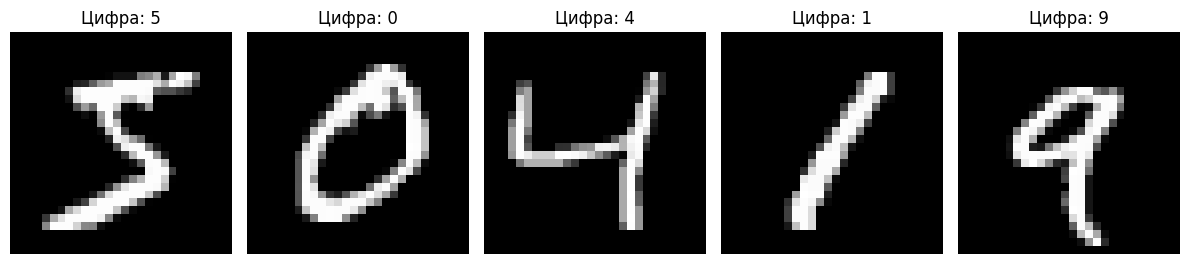

Пример 1: Цифра '5', размер изображения: torch.Size([1, 28, 28])
Пример 2: Цифра '0', размер изображения: torch.Size([1, 28, 28])
Пример 3: Цифра '4', размер изображения: torch.Size([1, 28, 28])
Пример 4: Цифра '1', размер изображения: torch.Size([1, 28, 28])
Пример 5: Цифра '9', размер изображения: torch.Size([1, 28, 28])


In [3]:
import matplotlib.pyplot as plt

# Берем первые 5 примеров из тренировочного набора
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    # Получаем i-й пример (изображение и метку)
    img, label = trainset[i]
    
    # Отображаем изображение (убираем канал, так как он один)
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'Цифра: {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Также можно вывести информацию
for i in range(5):
    img, label = trainset[i]
    print(f"Пример {i+1}: Цифра '{label}', размер изображения: {img.shape}")


In [4]:
class myModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()  
        self.linear1 = nn.Linear(784, 160)
        self.linear3 = nn.Linear(160, 392)  
        self.linear4 = nn.Linear(392, 10)
        self.gelu = nn.GELU()
    
    def forward(self, x):
        x = self.flatten(x)  
        
        out = self.linear1(x)
        out = self.gelu(out)
        out = self.linear3(out)
        out = self.gelu(out)
        out = self.linear4(out)
        
        return out  


In [5]:
class ModelAE(nn.Module):
    def __init__(self, input_dim=784, out_dim=2):  # latent dim
        super(ModelAE, self).__init__()
        self.flatten = nn.Flatten() 
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, out_dim)
        ) 
        
        self.decoder = nn.Sequential(
            nn.Linear(out_dim, 32),      # ← НЕТ flatten здесь!
            nn.ReLU(),
            nn.Linear(32, input_dim),
            #nn.Sigmoid() 
        )
    
    def Encode(self, x):
        x = self.flatten(x)           # [64,1,28,28] → [64,784]
        return self.encoder(x)        # [64, out_dim]
    
    def Decode(self, z):
        # z уже [64, out_dim] — НЕ нужен flatten!
        return self.decoder(z)        # [64, 784]
    
    def forward(self, x):
        z = self.Encode(x)            # Только один flatten!
        reconstructed = self.Decode(z) # [64, 784]
        return reconstructed.view(x.size(0), 1, 28, 28)  # [64,1,28,28]


In [6]:
class myModel_W_AE(nn.Module):
    def __init__(self, pretrain_ae, latent_dim = 2 ):
        super().__init__()
        self.flatten = nn.Flatten()

        # self.encoder = nn.Sequential(
        #     nn.Linear(784, 32),
        #     nn.ReLU(),
        #     nn.Linear(32, latent_dim)
        # ) 

        self.clasifier = nn.Sequential(
            nn.Linear(latent_dim, 160),
            nn.GELU(),
            nn.Linear(160, 392),
            nn.GELU(), 
            nn.Linear(392, 10)
        )
    
    def forward(self, x):
        x = self.flatten(x)  
        #x = self.encoderd(x)

        out = self.clasifier(x)
        
        return out  


In [7]:
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

get_device()

device(type='cuda')

epoch = 1 loss = 0.5735409125938253
epoch = 2 loss = 0.2051894471554433
epoch = 3 loss = 0.13709737676180014
epoch = 4 loss = 0.10406414217362969
epoch = 5 loss = 0.0821285376609382
epoch = 6 loss = 0.06570217619508
epoch = 7 loss = 0.057269998399888056
epoch = 8 loss = 0.04625738756257599
epoch = 9 loss = 0.03775596864900346
epoch = 10 loss = 0.030727492834804422


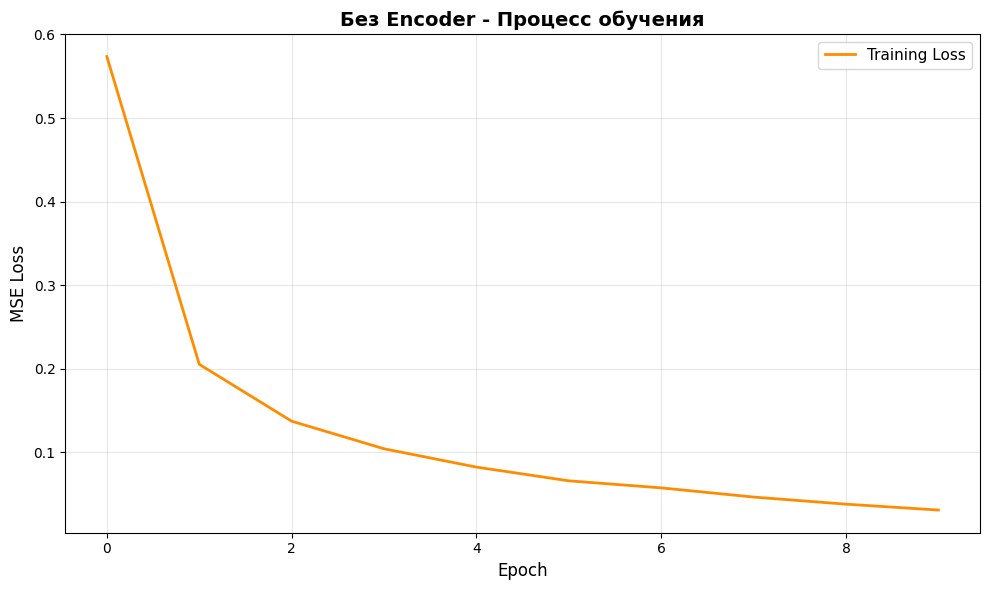

In [8]:
epoch = 10
losses = []

model = myModel().to(DEVICE)
optimizer = AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for i in range(epoch):
    model.train()
    train_loss = 0.0

    for x,target in train_loader:
        x = x.to(DEVICE)
        target = target.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(x)

        loss = criterion(outputs, target)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    losses.append(train_loss)
    print(f'epoch = {i + 1} loss = {train_loss}')

plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2, label='Training Loss', color='darkorange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Без Encoder - Процесс обучения', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()




In [9]:
from sklearn.metrics import classification_report
all_preds = []
all_targets = []

with torch.no_grad():
    for x, target in test_loader:
        outputs = model(x.to(DEVICE))
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

print(classification_report(all_targets, all_preds, digits=4))


              precision    recall  f1-score   support

           0     0.9798    0.9908    0.9853       980
           1     0.9886    0.9903    0.9894      1135
           2     0.9833    0.9729    0.9781      1032
           3     0.9696    0.9782    0.9739      1010
           4     0.9660    0.9847    0.9753       982
           5     0.9839    0.9619    0.9728       892
           6     0.9792    0.9812    0.9802       958
           7     0.9822    0.9660    0.9740      1028
           8     0.9539    0.9774    0.9655       974
           9     0.9798    0.9613    0.9705      1009

    accuracy                         0.9767     10000
   macro avg     0.9766    0.9765    0.9765     10000
weighted avg     0.9768    0.9767    0.9767     10000



In [10]:
# from sklearn.manifold import TSNE
# import matplotlib.pyplot as plt
# import numpy as np

# # Собираем все предсказания и истинные метки
# model.eval()
# all_features = []
# all_labels = []

# with torch.no_grad():
#     for x, y in test_loader:
#         x = x.to(DEVICE)
#         features = model.linear1(x.flatten(1))  # Берем первые признаки
#         all_features.append(features.cpu())
#         all_labels.append(y)

# # Объединяем
# all_features = torch.cat(all_features).numpy()
# all_labels = torch.cat(all_labels).numpy()

# # t-SNE снижение размерности до 2D
# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# features_2d = tsne.fit_transform(all_features)

# # Визуализация
# plt.figure(figsize=(12, 8))
# scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], 
#                      c=all_labels, cmap='tab10', alpha=0.7, s=20)
# plt.colorbar(scatter, ticks=range(10))
# plt.title('t-SNE: Распределение признаков MNIST')
# plt.xlabel('t-SNE 1')
# plt.ylabel('t-SNE 2')
# plt.show()


In [11]:
model_ae = ModelAE(784, 2).to(DEVICE)
optimizer = AdamW(model_ae.parameters(), lr=0.001)
criterion = nn.MSELoss()

epoch 1  loss = 0.8718716643624387
epoch 2  loss = 0.6393233194189557
epoch 3  loss = 0.5953482591499717
epoch 4  loss = 0.5811291902752246
epoch 5  loss = 0.5725815760887275


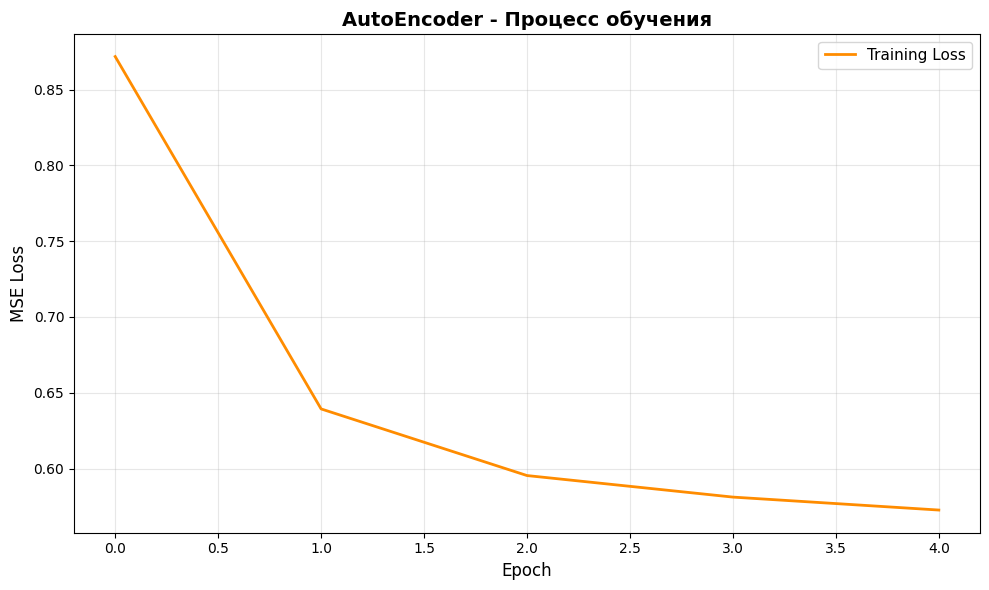

In [12]:
epoch = 5
losses = []

for i in range(epoch):
    model_ae.train()
    train_loss = 0.0

    for x, _ in train_loader:
        x = x.to(DEVICE)

        optimizer.zero_grad()

        outputs = model_ae(x)

        loss = criterion(outputs, x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    losses.append(train_loss)
    print(f'epoch {i + 1}  loss = {train_loss}')


plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2, label='Training Loss', color='darkorange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('AutoEncoder - Процесс обучения', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
        


In [13]:
model = ModelAE(out_dim=2)  # latent_dim = 128

# Берем батч
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(f"Оригинал: {images.shape}")  # [1024, 1, 28, 28] → 1024 × 784 floats

z = model.Encode(images)
print(f"Сжатые (latent): {z.shape}")  # [1024, 128] → 1024 × 128 floats (~6x меньше!)

recon = model.forward(images)
print(f"Реконструкция: {recon.shape}")  # Обратно [1024, 1, 28, 28]
print(f"Размер сжатых данных: {z.numel() * 4 / 1024:.1f} KB")  # ~500 KB на батч
print(f"Размер оригинала: {images.numel() * 4 / 1024:.1f} KB")  # ~3 MB на батч


Оригинал: torch.Size([1024, 1, 28, 28])
Сжатые (latent): torch.Size([1024, 2])
Реконструкция: torch.Size([1024, 1, 28, 28])
Размер сжатых данных: 8.0 KB
Размер оригинала: 3136.0 KB


epoch = 1 loss = 1.6749668464822285 
epoch = 2 loss = 1.5819152371358063 
epoch = 3 loss = 1.5753493915169925 
epoch = 4 loss = 1.5710492740243167 
epoch = 5 loss = 1.5696527978121224 
epoch = 6 loss = 1.569151969279273 
epoch = 7 loss = 1.5684343616841203 
epoch = 8 loss = 1.5670442904456188 
epoch = 9 loss = 1.5659115556943215 
epoch = 10 loss = 1.5648301940853313 


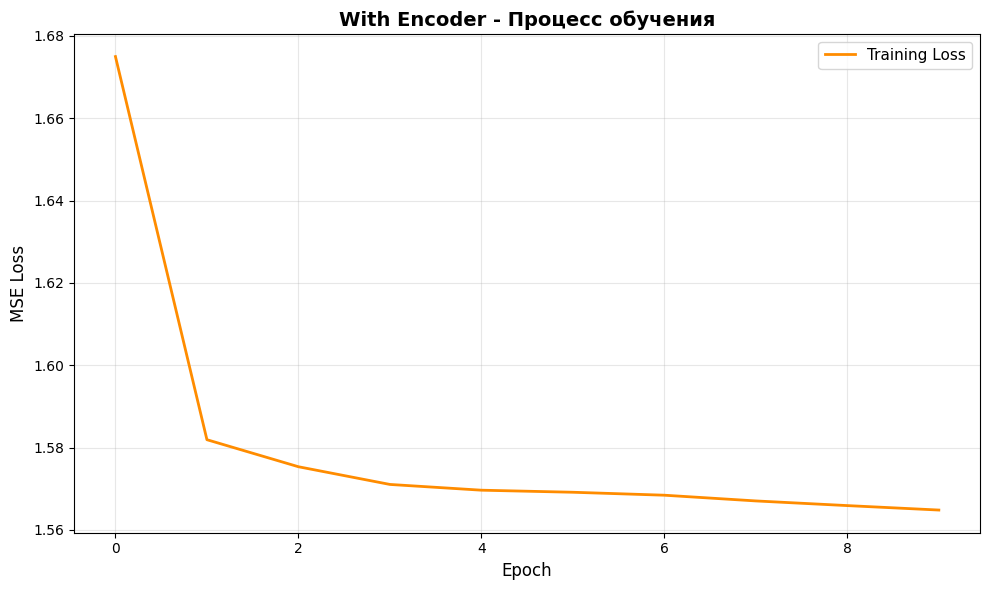

In [ ]:
model_ae.eval()
for param in model_ae.parameters():
    param.requires_grad = False

epoch = 10
losses = []

model = myModel_W_AE(model_ae, latent_dim = 2).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for i in range(epoch):
    model.train()
    train_loss = 0.0

    for x,target in train_loader:
        x = x.to(DEVICE)
        with torch.no_grad():  
            x = model_ae.Encode(x)

        target = target.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(x)

        loss = criterion(outputs, target)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    losses.append(train_loss)
    print(f'epoch = {i + 1} loss = {train_loss} ')

plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2, label='Training Loss', color='darkorange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('With Encoder - Процесс обучения', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
all_preds = []
all_targets = []

with torch.no_grad():
    for x, target in test_loader:
        x = x.to(DEVICE)
        x = model_ae.Encode(x)
        outputs = model(x)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

print(classification_report(all_targets, all_preds, digits=4))


              precision    recall  f1-score   support

           0     0.7934    0.8112    0.8022       980
           1     0.8078    0.9075    0.8548      1135
           2     0.2342    0.1541    0.1859      1032
           3     0.2222    0.0495    0.0810      1010
           4     0.2527    0.3625    0.2978       982
           5     0.1190    0.0056    0.0107       892
           6     0.3424    0.5919    0.4338       958
           7     0.2978    0.4679    0.3640      1028
           8     0.4141    0.4281    0.4210       974
           9     0.2569    0.2775    0.2668      1009

    accuracy                         0.4140     10000
   macro avg     0.3741    0.4056    0.3718     10000
weighted avg     0.3812    0.4140    0.3801     10000



In [ ]:
# from sklearn.manifold import TSNE
# import matplotlib.pyplot as plt
# import numpy as np

# # Собираем все предсказания и истинные метки
# model.eval()
# all_features = []
# all_labels = []

# with torch.no_grad():
#     for x, y in test_loader:
#         x = x.to(DEVICE)
#         features = model.encoder(x.flatten(1))  # Берем первые признаки
#         all_features.append(features.cpu())
#         all_labels.append(y)

# # Объединяем
# all_features = torch.cat(all_features).numpy()
# all_labels = torch.cat(all_labels).numpy()

# # t-SNE снижение размерности до 2D
# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# features_2d = tsne.fit_transform(all_features)

# # Визуализация
# plt.figure(figsize=(12, 8))
# scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], 
#                      c=all_labels, cmap='tab10', alpha=0.7, s=20)
# plt.colorbar(scatter, ticks=range(10))
# plt.title('t-SNE: Распределение признаков MNIST')
# plt.xlabel('t-SNE 1')
# plt.ylabel('t-SNE 2')
# plt.show()
